<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/DSR_44_Embeddings_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf # Tensors flowing through a data flow graph
from tensorflow.keras import models, layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [4]:
!nvidia-smi

Tue Oct 21 12:30:07 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
dataset, info = tfds.load(
    "imdb_reviews/plain_text",
    split=["train", "test[:50%]", "test[50%:]"],
    as_supervised=True,
    with_info=True
)
info
dataset_train_original = dataset[0]
dataset_validate_original = dataset[1]
dataset_test_original = dataset[2]
info

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9NGBKZ_1.0.0/imdb_reviews-train.tfrecor…

...

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9NGBKZ_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9NGBKZ_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_e

In [6]:
dataset_train = dataset_train_original.cache()
dataset_train = dataset_train.shuffle(25_000)
dataset_train = dataset_train.batch(128)

dataset_validate = dataset_validate_original.cache()
dataset_validate = dataset_validate.batch(128)

dataset_test = dataset_test_original.cache()
dataset_test = dataset_test.batch(128)

In [7]:
def render_history(history):
    plt.title("Training loss vs. validation loss")
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.legend()
    plt.show()
    plt.close()

    plt.title("Training accuracy vs. validation accuracy")
    plt.plot(history.history["accuracy"], label="accuracy")
    plt.plot(history.history["val_accuracy"], label="val_accuracy")
    plt.legend()
    plt.show()
    plt.close()

In [8]:
"Word Embeddings"

'Word Embeddings'

In [11]:
vocabulary_size = 10_000
sequence_length = 128

# Proto-Tokenizer
encoder = layers.TextVectorization(
    max_tokens=vocabulary_size, # Not new!
    output_sequence_length=sequence_length, # New!
    standardize="lower_and_strip_punctuation", # Not new!
    split="whitespace", # Not new!
    output_mode="int" # New!
)
encoder.adapt(dataset_train_original.map(lambda text, _: text).batch(25_000))

In [13]:
vocabulary = encoder.get_vocabulary()
vocabulary = [str(word) for word in vocabulary]
print(vocabulary)

['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not', 'you', 'are', 'his', 'have', 'he', 'be', 'one', 'its', 'at', 'all', 'by', 'an', 'they', 'from', 'who', 'so', 'like', 'her', 'just', 'or', 'about', 'has', 'if', 'out', 'some', 'there', 'what', 'good', 'when', 'more', 'very', 'even', 'she', 'my', 'no', 'up', 'would', 'which', 'only', 'time', 'really', 'story', 'their', 'were', 'had', 'see', 'can', 'me', 'than', 'we', 'much', 'well', 'been', 'get', 'will', 'into', 'also', 'because', 'other', 'do', 'people', 'bad', 'great', 'first', 'how', 'most', 'him', 'dont', 'made', 'then', 'movies', 'make', 'films', 'could', 'way', 'them', 'any', 'too', 'after', 'characters', 'think', 'watch', 'two', 'many', 'being', 'seen', 'character', 'never', 'little', 'acting', 'where', 'plot', 'best', 'love', 'did', 'know', 'life', 'show', 'does', 'ever', 'your', 'still', 'better', 'over', 'off', 'these', 'end

In [14]:
text = "A beginning is a very delicate time. Know than that it is the year 10191. The know universe is ruled by the Padishah Emperor Shaddam IV. My father"
encoder(text)

<tf.Tensor: shape=(128,), dtype=int64, numpy=
array([   4,  445,    7,    4,   53, 5739,   62,  118,   71,   12,    9,
          7,    2,  336,    1,    2,  118, 2519,    7, 8025,   33,    2,
          1, 5341,    1, 5674,   56,  338,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0])>

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 128)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 128, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,097 (1.24 MB)

 Trainable params: 324,097 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5767 - loss: 0.6744 - val_accuracy: 0.7896 - val_loss: 0.4666
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8462 - loss: 0.3822 - val_accuracy: 0.8398 - val_loss: 0.3690
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9064 - loss: 0.2570 - val_accuracy: 0.8375 - val_loss: 0.3681
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9448 - loss: 0.1797 - val_accuracy: 0.8372 - val_loss: 0.3712
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9732 - loss: 0.1213 - val_accuracy: 0.8355 - val_loss: 0.3872


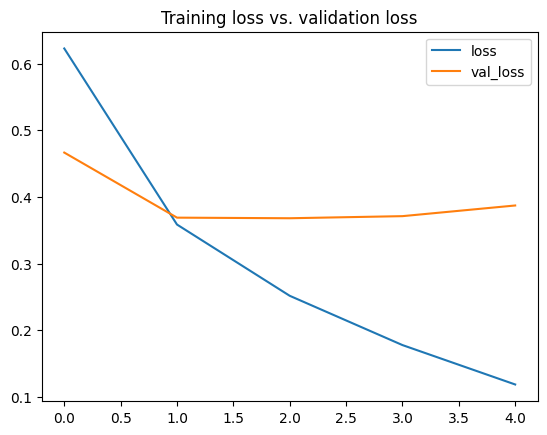

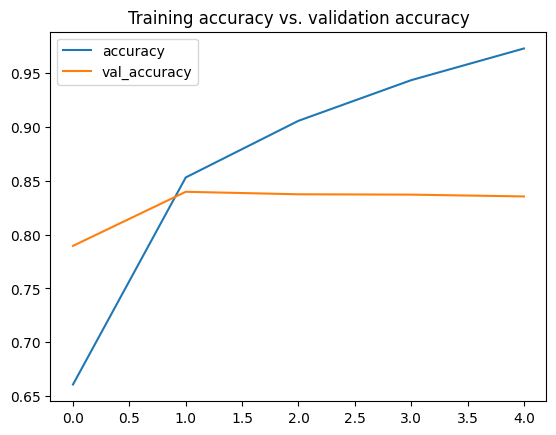

In [23]:
embedding_size = 32

model = models.Sequential()
model.add(encoder) # Sequence of word indices.
model.add(layers.Embedding(input_dim=vocabulary_size, output_dim=embedding_size)) # Sequence of word vectors.
model.add(layers.Reshape((sequence_length * embedding_size,)))
model.add(layers.Dense(1, activation="sigmoid")) # Good movie vs. bad movie classification
model.build(input_shape=(None,))
model.summary()

# prediction = model.predict(tf.constant(["Jesus Christ Super Star is a great musical. I like the dialogue. The lights were great. Music was in key and rhythm."]))
# plt.imshow(prediction[0].T, cmap="inferno")

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    dataset_train,
    epochs=5,
    validation_data=dataset_validate
)
render_history(history)